# 🏏 IPL Data Analysis & Visualization

### 📊 Project Overview
This notebook performs Exploratory Data Analysis (EDA) on IPL datasets using:
- **Pandas** for data manipulation
- **Seaborn & Matplotlib** for visualization

### 🎯 Objectives
- Analyze player performance
- Evaluate team success
- Identify match patterns (toss, death overs, etc.)

## 📦 IMPORT LIBRARIES

In [3]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12,6)

## 📂 LOAD DATA

In [4]:
# Load datasets
matches = pd.read_csv("../data/raw_data/ipl_matches_data.csv", encoding="latin1")
deliveries = pd.read_csv("../data/raw_data/ball_by_ball_data.csv", encoding="latin1")
players = pd.read_csv("../data/raw_data/players-data-updated.csv", encoding="latin1")
teams = pd.read_csv("../data/raw_data/teams_data.csv", encoding="latin1")

# Display first few rows
matches.head()

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result,stage
0,335982,2008,6,Bangalore,18-04-2008,Indian Premier League,1.0,male,T20,T20,...,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,field,Kolkata Knight Riders,140.0,NaN,46.0,win,NaN
1,1082591,2017,6,Hyderabad,05-04-2017,Indian Premier League,1.0,male,T20,T20,...,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,15.0,win,NaN
2,1082592,2017,6,Pune,06-04-2017,Indian Premier League,2.0,male,T20,T20,...,Rising Pune Supergiant,Rising Pune Supergiant,Mumbai Indians,field,Rising Pune Supergiant,NaN,7.0,36.0,win,NaN
3,1082593,2017,6,Rajkot,07-04-2017,Indian Premier League,3.0,male,T20,T20,...,Kolkata Knight Riders,Gujarat Lions,Kolkata Knight Riders,field,Kolkata Knight Riders,NaN,10.0,57.0,win,NaN
4,1082594,2017,6,Indore,08-04-2017,Indian Premier League,4.0,male,T20,T20,...,Punjab Kings,Punjab Kings,Rising Pune Supergiant,field,Punjab Kings,NaN,6.0,71.0,win,NaN


## 🔍 DATA OVERVIEW

In [5]:
# Basic info
print("Matches Data:")
display(matches.info())

print("\nDeliveries Data:")
display(deliveries.info())

Matches Data:
<class 'pandas.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   match_id         1169 non-null   int64  
 1   season_id        1169 non-null   int64  
 2   balls_per_over   1169 non-null   int64  
 3   city             1118 non-null   str    
 4   match_date       1169 non-null   str    
 5   event_name       1169 non-null   str    
 6   match_number     1099 non-null   float64
 7   gender           1169 non-null   str    
 8   match_type       1169 non-null   str    
 9   format           1169 non-null   str    
 10  overs            1169 non-null   int64  
 11  season           1169 non-null   str    
 12  team_type        1169 non-null   str    
 13  venue            1169 non-null   str    
 14  toss_winner      1168 non-null   str    
 15  team1            1169 non-null   str    
 16  team2            1169 non-null   str    
 17  toss_decisi

None


Deliveries Data:
<class 'pandas.DataFrame'>
RangeIndex: 278205 entries, 0 to 278204
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   season_id          278205 non-null  int64
 1   match_id           278205 non-null  int64
 2   batter             278205 non-null  str  
 3   bowler             278205 non-null  str  
 4   non_striker        278205 non-null  str  
 5   team_batting       278205 non-null  str  
 6   team_bowling       278205 non-null  str  
 7   over_number        278205 non-null  int64
 8   ball_number        278205 non-null  int64
 9   batter_runs        278205 non-null  int64
 10  extras             278205 non-null  int64
 11  total_runs         278205 non-null  int64
 12  batsman_type       278205 non-null  str  
 13  bowler_type        278205 non-null  str  
 14  player_out         13823 non-null   str  
 15  fielders_involved  13823 non-null   str  
 16  is_wicket          278205 non-n

None

## 🏏 TOP BATSMEN

C:\Users\chand\AppData\Local\Temp\ipykernel_13160\4247051238.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette="viridis")
C:\Users\chand\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


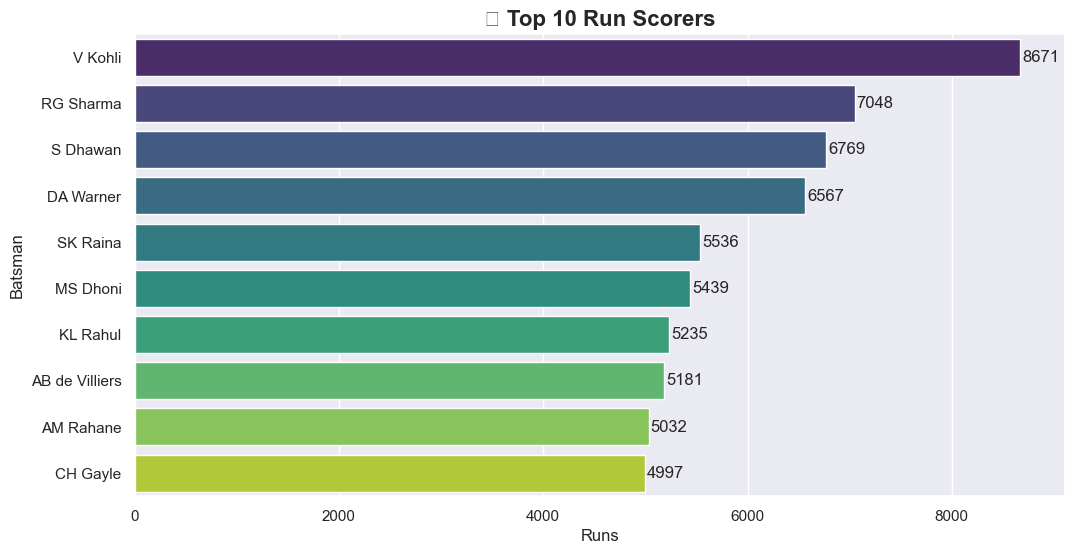

In [6]:
# Top 10 run scorers
top_batsmen = (
    deliveries.groupby("batter")["batter_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure()
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette="viridis")

plt.title("🏏 Top 10 Run Scorers", fontsize=16, weight='bold')
plt.xlabel("Runs")
plt.ylabel("Batsman")

# Add labels
for i, v in enumerate(top_batsmen.values):
    plt.text(v + 20, i, str(v), va='center')

plt.show()

## ⚡STRIKE RATE ANALYSIS

C:\Users\chand\AppData\Local\Temp\ipykernel_13160\2397572735.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sr["strike_rate"], y=top_sr.index, palette="magma")
C:\Users\chand\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


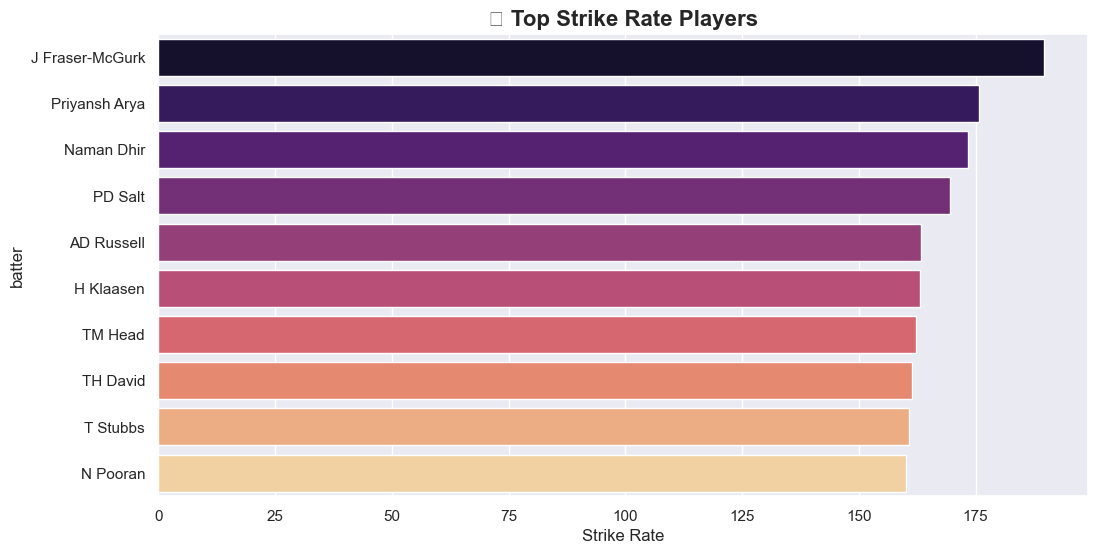

In [7]:
# Calculate strike rate
batsman_stats = deliveries.groupby("batter").agg(
    runs=("batter_runs", "sum"),
    balls=("batter_runs", "count")
)

batsman_stats = batsman_stats[batsman_stats["balls"] > 200]
batsman_stats["strike_rate"] = (batsman_stats["runs"] / batsman_stats["balls"]) * 100

top_sr = batsman_stats.sort_values("strike_rate", ascending=False).head(10)

# Plot
plt.figure()
sns.barplot(x=top_sr["strike_rate"], y=top_sr.index, palette="magma")

plt.title("⚡ Top Strike Rate Players", fontsize=16, weight='bold')
plt.xlabel("Strike Rate")

plt.show()

## 🎯 TOP BOWLERS

C:\Users\chand\AppData\Local\Temp\ipykernel_13160\822763139.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette="coolwarm")
C:\Users\chand\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


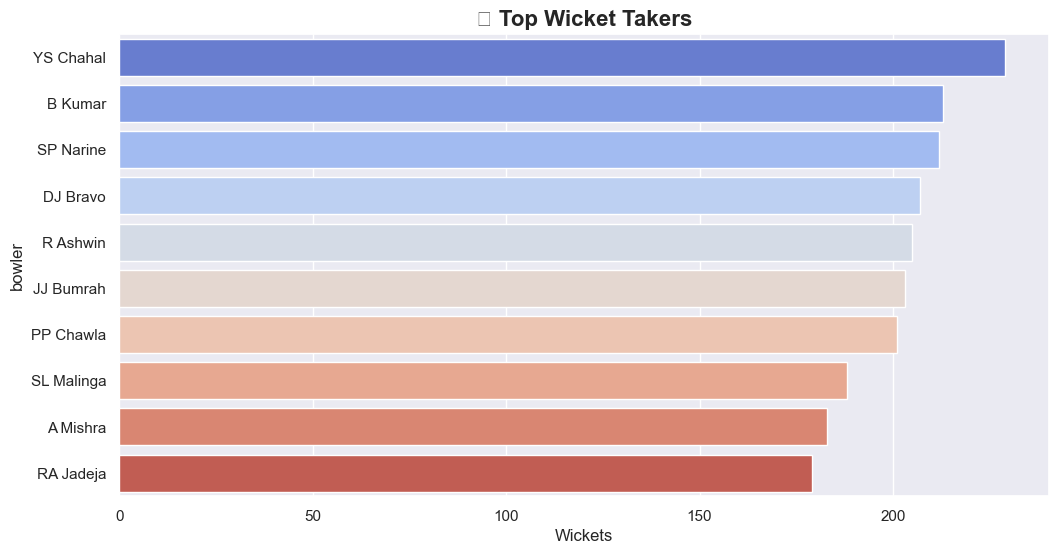

In [8]:
# Top wicket takers
top_bowlers = (
    deliveries[deliveries["is_wicket"] == 1]
    .groupby("bowler")["is_wicket"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure()
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette="coolwarm")

plt.title("🎯 Top Wicket Takers", fontsize=16, weight='bold')
plt.xlabel("Wickets")

plt.show()

## 🏆 TEAM PERFORMANCE

C:\Users\chand\AppData\Local\Temp\ipykernel_13160\726501145.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_wins.values, y=team_wins.index, palette="cubehelix")
C:\Users\chand\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


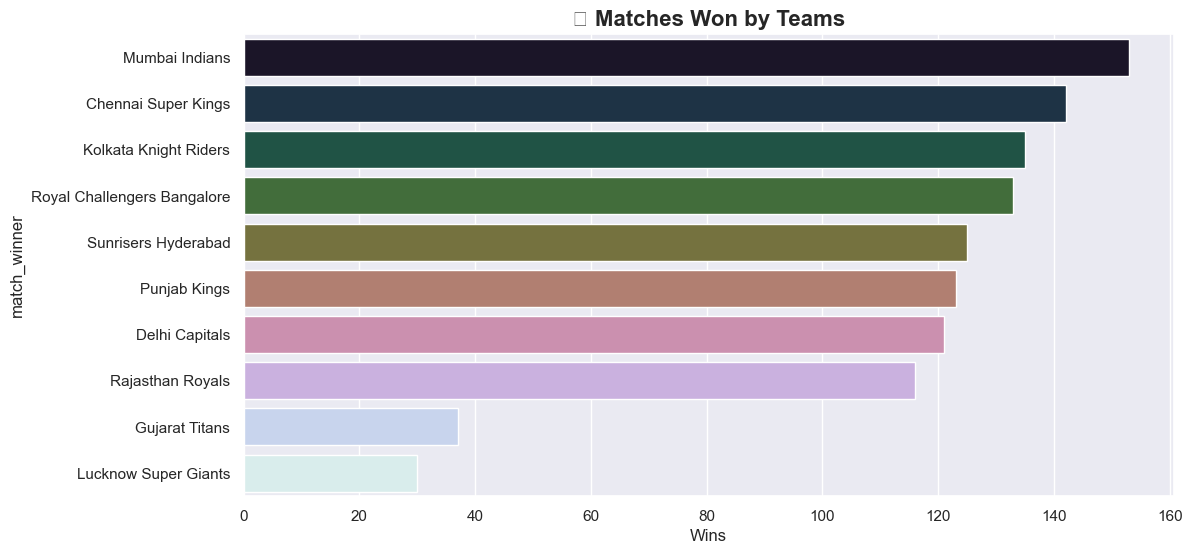

In [9]:
# Matches won
team_wins = matches["match_winner"].value_counts().head(10)

plt.figure()
sns.barplot(x=team_wins.values, y=team_wins.index, palette="cubehelix")

plt.title("🏆 Matches Won by Teams", fontsize=16, weight='bold')
plt.xlabel("Wins")

plt.show()

## 📈 SEASON TREND

C:\Users\chand\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


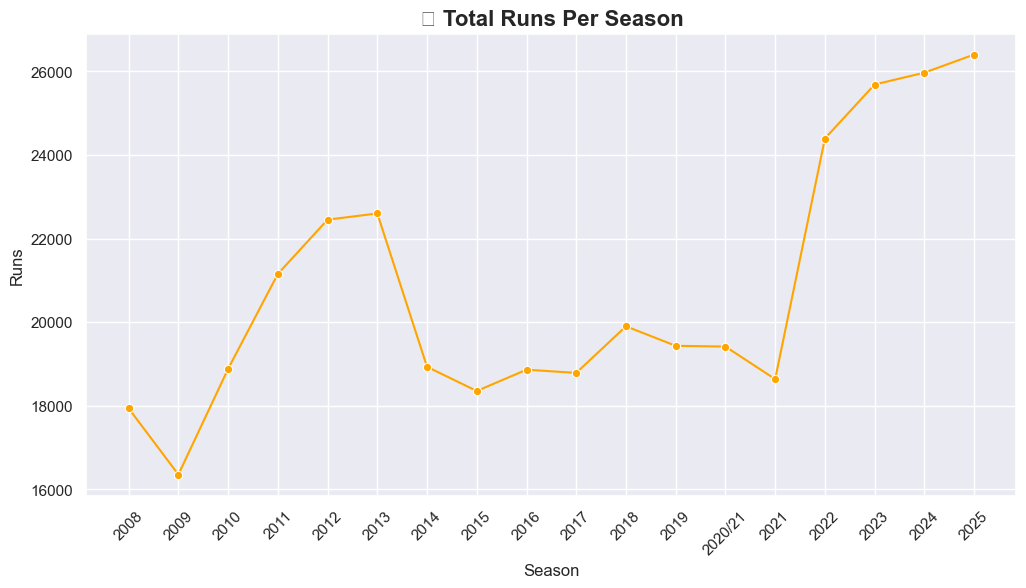

In [10]:
# Merge data
merged = matches.merge(deliveries, on="match_id")

season_runs = merged.groupby("season")["total_runs"].sum()

# Plot
plt.figure()
sns.lineplot(x=season_runs.index, y=season_runs.values, marker="o", color="orange")

plt.title("📈 Total Runs Per Season", fontsize=16, weight='bold')
plt.xlabel("Season")
plt.ylabel("Runs")

plt.xticks(rotation=45)
plt.show()

## 🔥 RUN DISTRIBUTION

C:\Users\chand\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


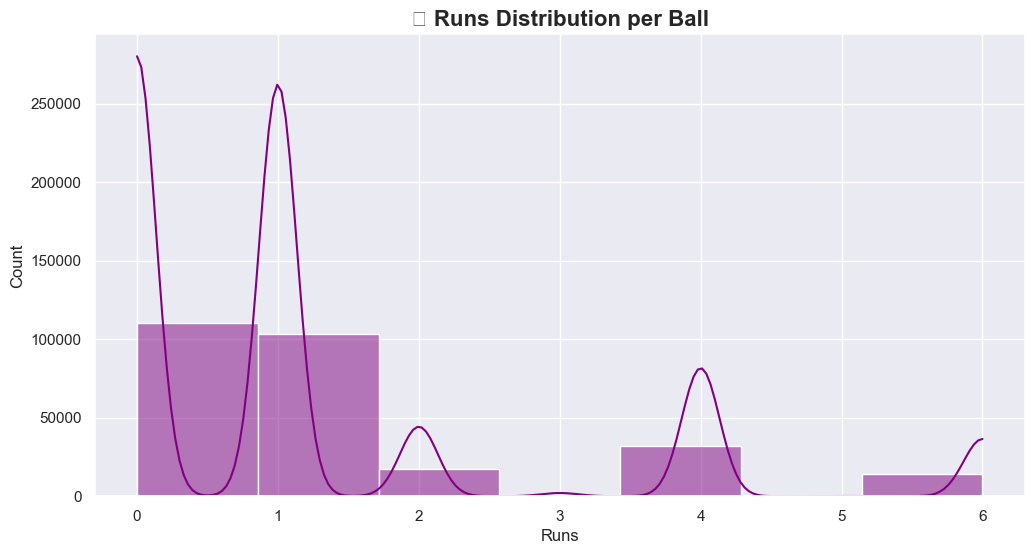

In [11]:
plt.figure()
sns.histplot(deliveries["batter_runs"], bins=7, kde=True, color="purple")

plt.title("🔥 Runs Distribution per Ball", fontsize=16, weight='bold')
plt.xlabel("Runs")

plt.show()

## 💀 DEATH OVER ANALYSIS

C:\Users\chand\AppData\Local\Temp\ipykernel_13160\3824412981.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=death_runs.values, y=death_runs.index, palette="rocket")
C:\Users\chand\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


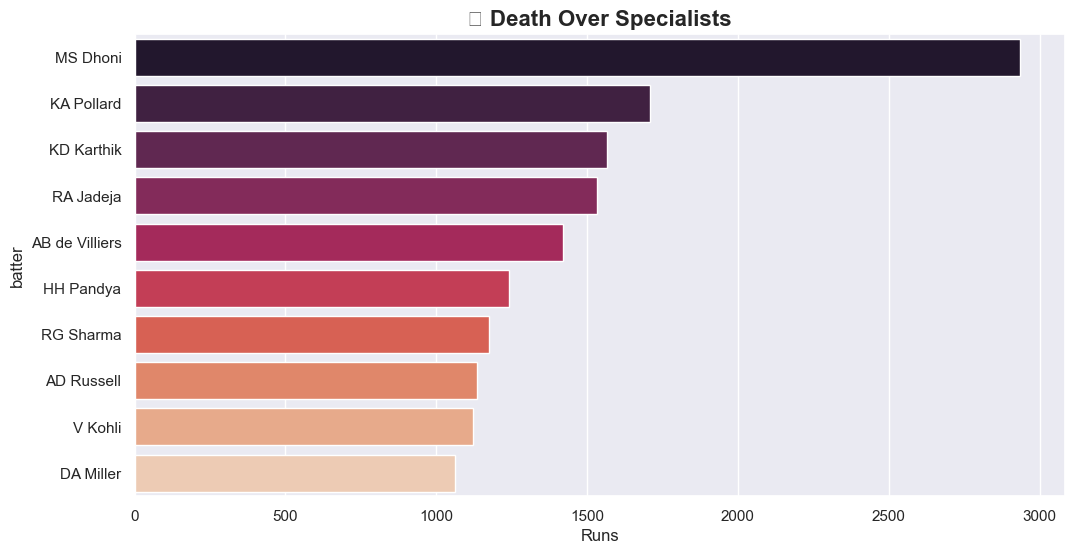

In [12]:
death = deliveries[deliveries["over_number"] >= 16]

death_runs = (
    death.groupby("batter")["batter_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
sns.barplot(x=death_runs.values, y=death_runs.index, palette="rocket")

plt.title("💀 Death Over Specialists", fontsize=16, weight='bold')
plt.xlabel("Runs")

plt.show()

## 🎲 TOSS IMPACT

C:\Users\chand\AppData\Local\Temp\ipykernel_13160\602212384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=matches["toss_win_match_win"], palette="pastel")
C:\Users\chand\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127922 (\N{GAME DIE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


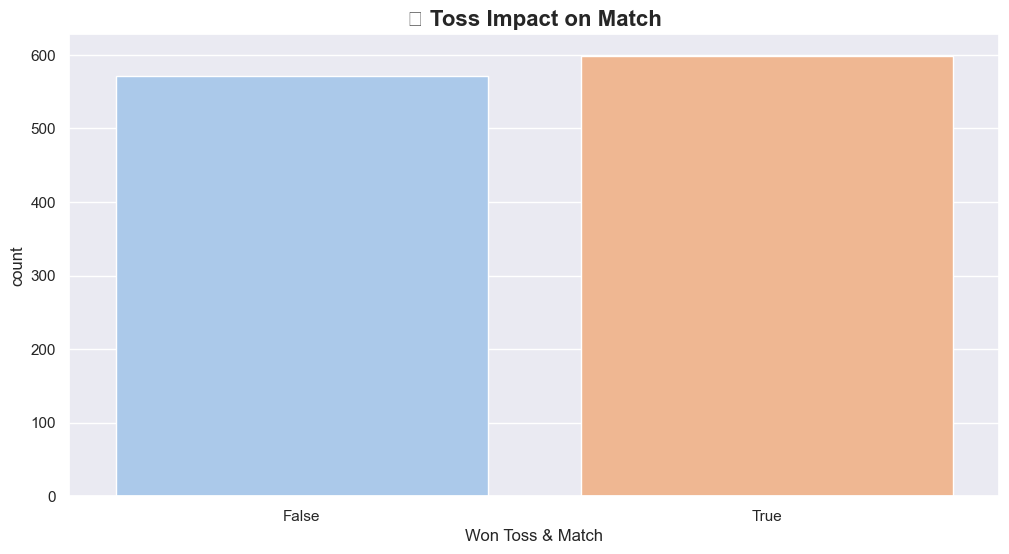

In [13]:
matches["toss_win_match_win"] = matches["toss_winner"] == matches["match_winner"]

sns.countplot(x=matches["toss_win_match_win"], palette="pastel")

plt.title("🎲 Toss Impact on Match", fontsize=16, weight='bold')
plt.xlabel("Won Toss & Match")

plt.show()

## 📊 HEATMAP

C:\Users\chand\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


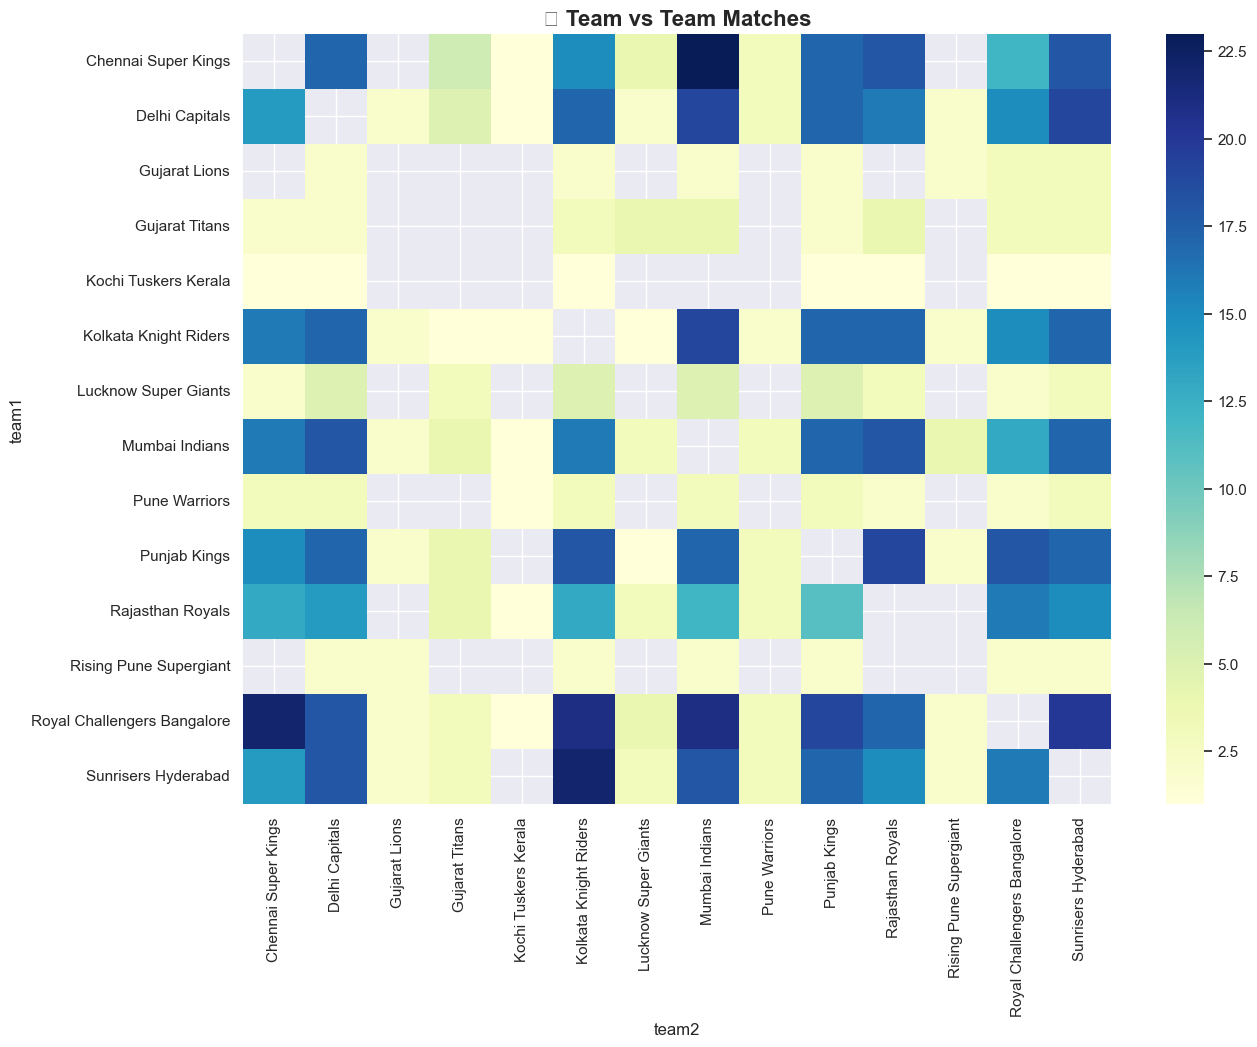

In [14]:
team_matrix = matches.pivot_table(
    index="team1",
    columns="team2",
    values="match_id",
    aggfunc="count"
)

plt.figure(figsize=(14,10))
sns.heatmap(team_matrix, cmap="YlGnBu", annot=False)

plt.title("📊 Team vs Team Matches", fontsize=16, weight='bold')

plt.show()

# CONCLUSION

## ✅ Key Insights

- Top batsmen dominate across seasons
- Strike rate varies significantly among players
- Toss has moderate impact on match results
- Death overs play a crucial role in match outcomes

### 🚀 Future Work
- Add machine learning for match prediction
- Build Power BI dashboard
- Add interactive visualizations (Plotly)